# Fashion Style Classification Baseline

## 1. Objective
The objective of this notebook is to build and evaluate a first baseline image classification model that predicts the style of individual clothing items.

The project focuses on four fashion styles:

- casual
- formal
- sporty
- streetwear

This notebook approaches the task as a single-label multiclass classification problem, where each image belongs to exactly one style class.

The purpose of this first baseline is to test whether the manually collected dataset and style definitions are learnable by a machine learning model. This serves as the foundation for a later recommendation system, where predicted style and clothing type can be used to suggest compatible outfit items.

## 2. Project Context

Fashion recommendation is an interesting machine learning problem because compatibility between clothing items is not defined by one simple rule. Items may work well together based on style, color, silhouette, or overall visual identity, and more than one recommendation may be valid for the same input item. This makes direct outfit recommendation more subjective and structurally more difficult than standard classification tasks.

Because of this, the first iteration of the project does not attempt to predict full outfit compatibility directly. Instead, it focuses on a simpler and more manageable task: predicting the style of an individual clothing item from an image.

This decision also follows the project guidance received during feedback discussions. A direct “matching” or “outfit completion” system would require a more complex definition of compatibility and a stronger dataset. In contrast, style prediction provides a clearer starting point for building and evaluating a baseline model.

The assumption behind this approach is that style can later serve as a useful intermediate representation for recommendation. If a model can reliably predict whether an item belongs to a style such as casual, formal, sporty, or streetwear, this prediction can later be combined with clothing type information to retrieve other items of the same style and a different type. In that way, style classification becomes the foundation for a later recommendation system.

## 3. Dataset Design and Collection Approach

The dataset used in this notebook was manually curated for the first baseline experiment. Rather than relying directly on an existing fashion dataset, the images were collected from online fashion sources and organized according to a custom labeling scheme designed for this project.

The dataset was structured around two dimensions:

- **style**
- **clothing type**

The four style classes are:

- casual
- formal
- sporty
- streetwear

The four clothing types included in the current version of the dataset are:

- tshirt
- pants
- shoes
- jacket

For each style-type combination, 10 images were collected, resulting in:

- 4 styles
- 4 clothing types
- 10 images per combination
- **160 images in total**

Although the dataset includes both style and clothing type information, the first baseline model in this notebook uses only the **style labels** as prediction targets. Clothing type is included in the dataset structure because it will be useful in later stages of the project, especially when extending the system toward recommendation or outfit completion.

The images were selected manually in order to keep the first dataset relatively clean and consistent. Where possible, preference was given to product-style images with:

- a single dominant clothing item
- relatively plain backgrounds
- clear visibility of the item
- visually consistent presentation

This design choice was intended to reduce unnecessary noise in the first experiment and make it easier to test whether the selected style categories are visually learnable.

## 4. Label Definitions and Dataset Rules

Because the dataset was manually curated, labeling rules were defined before model training in order to keep the classes as consistent as possible.

A detailed version of these rules is stored in the project repository under:

`dataset/metadata/dataset_rules.md`

This file contains the full style definitions, clothing type definitions, and dataset assignment rules used during data collection and organization.

In summary, the dataset uses four style classes:

- casual
- formal
- sporty
- streetwear

and four clothing types:

- tshirt
- pants
- shoes
- jacket

Each image was assigned to one style and one clothing type, and ambiguous items were avoided during collection whenever possible.

## 5. Folder Structure, Metadata, and Training Split

The dataset was organized in multiple stages in order to keep the workflow structured and reproducible.

### 5.1. Dataset Organization

The project dataset is stored in a dedicated `dataset` folder in the repository. The main dataset stages are:

- `raw/` for the initially collected images
- `cleaned/` for the reviewed dataset used for experiments
- `metadata/` for supporting files such as labeling rules and image metadata
- `split_style/` for the final train, validation, and test split used in the first baseline

The cleaned dataset was structured by both style and clothing type. This allowed the project to preserve type information for later recommendation experiments, while still supporting a style-only baseline in the first notebook.

### 5.2. Metadata

A metadata file named `labels.csv` was generated automatically from the cleaned folder structure. This file stores, for each image:

- filename
- style
- type

Although the first baseline uses only the style labels for training, the metadata file helps document the dataset and supports future extensions of the project.

### 5.3. Style-Only Training Split

For the first baseline, the dataset was converted into a style-only split. Images from all clothing types belonging to the same style were grouped together into one class folder. This created a standard image-classification structure with separate training, validation, and test folders for the four style classes.

The final split used in this notebook contains:

- **Train:** 28 images per style
- **Validation:** 6 images per style
- **Test:** 6 images per style

This results in a balanced style-classification dataset with four classes:

- casual
- formal
- sporty
- streetwear

## 6. Import Libraries

The first step of the implementation is to import the libraries required for data loading, visualization, model training, and evaluation.

**PyTorch** and **torchvision** are used for the image classification pipeline, while **matplotlib** is used for visual inspection and sklearn is used for evaluation metrics such as the classification report and confusion matrix.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
  print("gpu name:", torch.cuda.get_device_name(0))

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

torch version: 2.11.0+cu130
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: CUDA


## 7. Dataset Paths and Image Transforms

The dataset used in this notebook is loaded from the `split_style` directory, which contains separate training, validation, and test folders for the four style classes.

Before training, the images are resized and transformed into tensors. Since the dataset is relatively small, simple preprocessing is used together with light augmentation for the training set only. This helps the model generalize slightly better without changing the class labels.

In [2]:
# Dataset paths
train_dir = "../dataset/split_style/train"
val_dir = "../dataset/split_style/val"
test_dir = "../dataset/split_style/test"

# Image transforms
train_transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.RandomHorizontalFlip(p=0.5),
  transforms.ToTensor(),
  transforms.Normalize(
      mean=[0.485, 0.456, 0.406],
      std=[0.229, 0.224, 0.225]
  )
])

eval_transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(
      mean=[0.485, 0.456, 0.406],
      std=[0.229, 0.224, 0.225]
  )
])

## 8. Load the Dataset

The training, validation, and test datasets are loaded using `ImageFolder`, which automatically assigns class labels based on the folder names.

Data loaders are then created to make it easier to iterate through the dataset in mini-batches during training and evaluation.

In [3]:
# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# Create dataloaders
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Class names
class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Classes: ['formal', 'gothic', 'sporty', 'streetwear']
Number of classes: 4
Training images: 112
Validation images: 24
Test images: 24


## 9. Dataset Overview and Sample Images

Before training the model, it is useful to inspect the dataset structure and visualize a few sample images.

This helps confirm that:
- the four style classes were loaded correctly
- the dataset split is balanced
- the images appear as expected after preprocessing

### 9.1. Split Summary

In [4]:
# Display split sizes
split_summary = pd.DataFrame({
  "Split": ["Train", "Validation", "Test"],
  "Images": [len(train_dataset), len(val_dataset), len(test_dataset)]
})

split_summary

,Split,Images
0,Train,112
1,Validation,24
2,Test,24


### 9.2. Class Distribution

In [5]:
# Count images per class in each split
def count_images_per_class(dataset):
  counts = {class_name: 0 for class_name in dataset.classes}
  for _, label in dataset.samples:
    class_name = dataset.classes[label]
    counts[class_name] += 1
  return counts

train_counts = count_images_per_class(train_dataset)
val_counts = count_images_per_class(val_dataset)
test_counts = count_images_per_class(test_dataset)

class_distribution = pd.DataFrame({
  "Train": train_counts,
  "Validation": val_counts,
  "Test": test_counts
})

class_distribution

,Train,Validation,Test
formal,28,6,6
gothic,28,6,6
sporty,28,6,6
streetwear,28,6,6


### 9.3. Sample Images

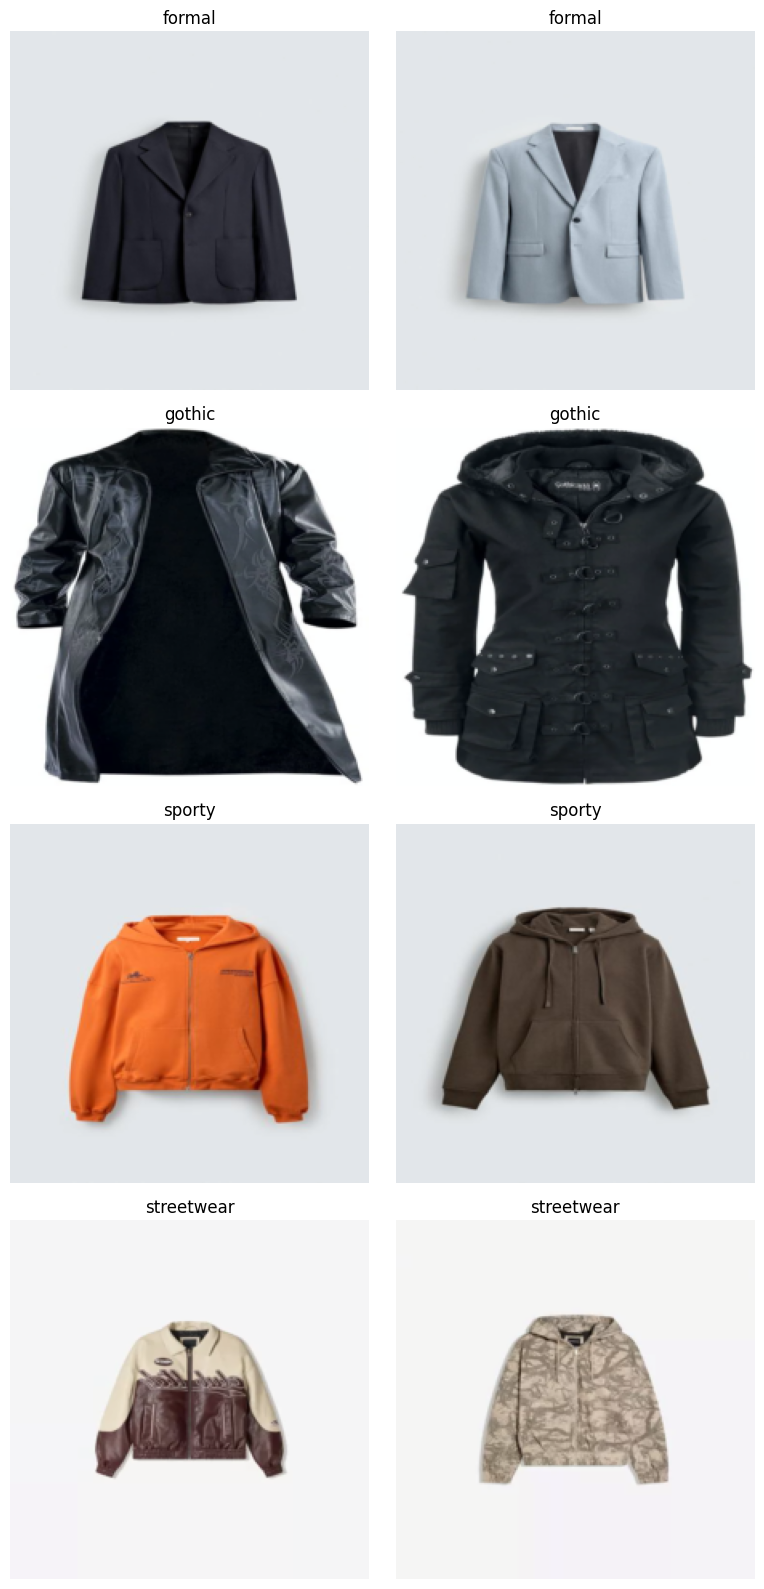

In [6]:
# Show 2 sample images per class
def show_images_per_class(dataset, class_names, images_per_class=2):
  fig, axes = plt.subplots(len(class_names), images_per_class, figsize=(4 * images_per_class, 4 * len(class_names)))

  if len(class_names) == 1:
    axes = np.expand_dims(axes, axis=0)

  class_indices = {i: [] for i in range(len(class_names))}

  for idx, (_, label) in enumerate(dataset.samples):
    if len(class_indices[label]) < images_per_class:
      class_indices[label].append(idx)

    if all(len(indices) == images_per_class for indices in class_indices.values()):
      break

  for class_idx, indices in class_indices.items():
    for j, sample_idx in enumerate(indices):
      image, label = dataset[sample_idx]

      image = image.permute(1, 2, 0).numpy()
      image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
      image = np.clip(image, 0, 1)

      axes[class_idx, j].imshow(image)
      axes[class_idx, j].set_title(class_names[label])
      axes[class_idx, j].axis("off")

  plt.tight_layout()
  plt.show()

show_images_per_class(train_dataset, class_names)

## 10. Baseline Model Selection

At the current stage of the project, the dataset is still relatively limited in size, since it was manually curated for an initial feasibility test. Because of this, training a deep convolutional neural network from scratch would not be the most practical choice for the first experiment. Instead, transfer learning is used.

A pretrained `ResNet18` model is selected as the baseline. ResNet18 is a widely used convolutional neural network architecture that has already learned general visual features from the ImageNet dataset. By reusing these learned representations and replacing the final classification layer, the model can be adapted to the four style classes in this project:

- casual
- formal
- sporty
- streetwear

ResNet18 is used here as a first benchmark because it provides a strong and efficient starting point. As the dataset grows in later iterations, this baseline can be extended or compared with other architectures.

In [7]:
# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final classification layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Move model to device
model = model.to(device)

## print(model)

## 11. Training Configuration

For the first baseline experiment, the pretrained feature extractor is frozen and only the final classification layer is trained. This keeps the training process simple and reduces the risk of overfitting on the current dataset.

The model is trained using:

- **CrossEntropyLoss** as the loss function
- **Adam** as the optimizer
- **10 epochs** for the initial experiment

This setup is intended to provide a stable first benchmark rather than a fully optimized final model.

In [8]:
# Freeze all pretrained layers
for param in model.parameters():
  param.requires_grad = False

# Unfreeze the final classification layer
for param in model.fc.parameters():
  param.requires_grad = True

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Training settings
num_epochs = 10

print("Training only the final classification layer.")
print("Number of epochs:", num_epochs)

Training only the final classification layer.
Number of epochs: 10


## 12. Training and Validation Loop

The model is trained for a fixed number of epochs using the training set, while performance on the validation set is monitored after each epoch.

Tracking both training and validation metrics is useful because it helps assess whether the model is learning meaningful patterns and whether it starts to overfit the small dataset.

In [9]:
# Lists to store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
  # ----- Training -----
  model.train()
  running_loss = 0.0
  correct_train = 0
  total_train = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)

    _, preds = torch.max(outputs, 1)
    correct_train += (preds == labels).sum().item()
    total_train += labels.size(0)

  epoch_train_loss = running_loss / total_train
  epoch_train_acc = correct_train / total_train

  train_losses.append(epoch_train_loss)
  train_accuracies.append(epoch_train_acc)

  # ----- Validation -----
  model.eval()
  running_val_loss = 0.0
  correct_val = 0
  total_val = 0

  with torch.no_grad():
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      running_val_loss += loss.item() * images.size(0)

      _, preds = torch.max(outputs, 1)
      correct_val += (preds == labels).sum().item()
      total_val += labels.size(0)

  epoch_val_loss = running_val_loss / total_val
  epoch_val_acc = correct_val / total_val

  val_losses.append(epoch_val_loss)
  val_accuracies.append(epoch_val_acc)

  print(
      f"Epoch [{epoch+1}/{num_epochs}] | "
      f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
      f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
  )

Epoch [1/10] | Train Loss: 1.4244 | Train Acc: 0.3304 | Val Loss: 1.3952 | Val Acc: 0.3750
Epoch [2/10] | Train Loss: 1.2316 | Train Acc: 0.4911 | Val Loss: 1.2705 | Val Acc: 0.3333
Epoch [3/10] | Train Loss: 1.0342 | Train Acc: 0.6250 | Val Loss: 1.1149 | Val Acc: 0.5417
Epoch [4/10] | Train Loss: 0.9512 | Train Acc: 0.6786 | Val Loss: 1.0744 | Val Acc: 0.4583
Epoch [5/10] | Train Loss: 0.7782 | Train Acc: 0.7946 | Val Loss: 0.9502 | Val Acc: 0.5833
Epoch [6/10] | Train Loss: 0.7607 | Train Acc: 0.7589 | Val Loss: 0.8996 | Val Acc: 0.6667
Epoch [7/10] | Train Loss: 0.6491 | Train Acc: 0.8661 | Val Loss: 0.8275 | Val Acc: 0.6250
Epoch [8/10] | Train Loss: 0.5656 | Train Acc: 0.8929 | Val Loss: 0.7914 | Val Acc: 0.6667
Epoch [9/10] | Train Loss: 0.5052 | Train Acc: 0.9286 | Val Loss: 0.7850 | Val Acc: 0.7083
Epoch [10/10] | Train Loss: 0.4770 | Train Acc: 0.9375 | Val Loss: 0.7183 | Val Acc: 0.7083


## 13. Training History

After training, the recorded loss and accuracy values can be visualized to better understand how the model behaved across epochs.

The training and validation curves help indicate whether the model is learning meaningful patterns and whether signs of overfitting appear during the first baseline experiment.

### 13.1. Loss plot

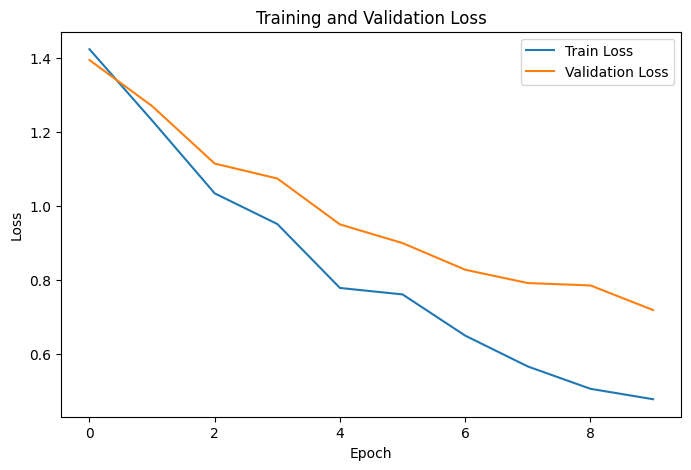

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 13.2. Accuracy plot

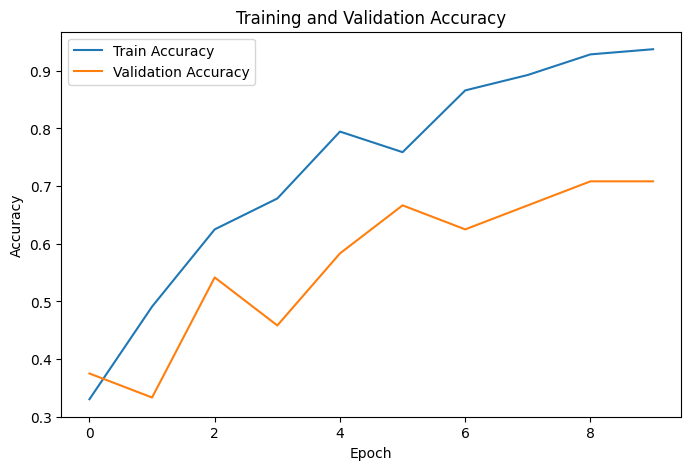

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 14. Test Set Evaluation

After training and validation, the final model is evaluated on the test set. This provides a clearer estimate of how well the baseline model generalizes to unseen fashion images.

The evaluation includes:

- test accuracy
- classification report
- confusion matrix

These results help identify not only the overall performance of the baseline, but also which style classes are easier or harder to distinguish.

### 14.1. Predictions and test accuracy

In [12]:
# Evaluate on the test set
model.eval()

all_preds = []
all_labels = []

correct_test = 0
total_test = 0

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

    correct_test += (preds == labels).sum().item()
    total_test += labels.size(0)

test_accuracy = correct_test / total_test
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7500


### 14.2. Classification report

In [13]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      formal       0.80      0.67      0.73         6
      gothic       1.00      1.00      1.00         6
      sporty       0.57      0.67      0.62         6
  streetwear       0.67      0.67      0.67         6

    accuracy                           0.75        24
   macro avg       0.76      0.75      0.75        24
weighted avg       0.76      0.75      0.75        24



### 14.3. Confusion matrix

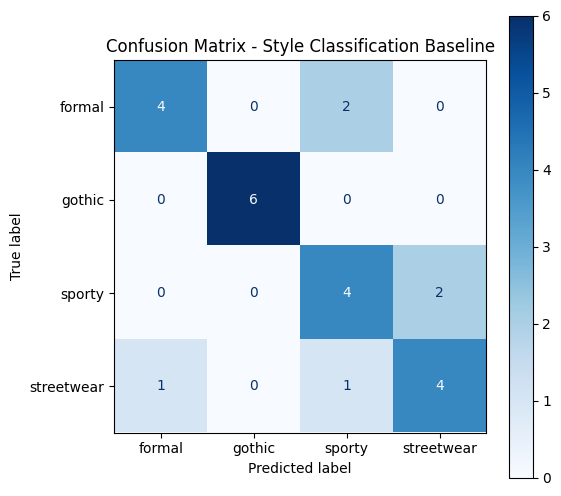

In [14]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Style Classification Baseline")
plt.show()

### 14.4. Results Interpretation

The baseline model achieved a test accuracy of **0.50**, with a macro F1-score of **0.48**. Since the task contains four balanced classes, this result is above the performance expected from random guessing and indicates that the model learned meaningful visual patterns from the dataset.

The strongest class was **formal**, which achieved the highest recall and F1-score. This suggests that formal clothing items were the most visually distinctive in the current dataset. In contrast, **casual** was the weakest class, which is understandable because casual clothing is broad and visually less specific than the other categories.

The **sporty** class achieved relatively high precision but low recall. This means that when the model predicted sporty, it was often correct, but it failed to identify many actual sporty items. This aligns with the earlier observation that sporty images were more difficult to collect consistently.

The model also showed confusion between **casual** and **streetwear**, suggesting that the boundary between these two styles is less clear in the current dataset. Overall, the results show that style classification is feasible as a first baseline, but the current dataset remains too small and limited for strong generalization across all four classes.

## 15. Limitations

This first baseline has several limitations.

**First**, the dataset is still relatively small, with only 160 images in total and only 24 images in the final test set. Because of this, the evaluation metrics are sensitive to small changes in prediction outcomes.

**Second**, the style labels are manually defined and partly subjective. While clear labeling rules were used, style boundaries are not always strict, especially between categories such as casual and streetwear.

**Third**, some classes were more difficult to collect consistently than others. In particular, sporty items were harder to gather in a visually clean and consistent way, which likely affected performance.

**Finally**, this baseline only focuses on style classification. It does not yet model outfit compatibility directly, nor does it use clothing type information during prediction. These aspects will need to be explored in later iterations of the project.

## 16. Conclusion

This notebook presented the first baseline experiment for the fashion recommendation project by approaching style recognition as a single-label multiclass image classification task.

Using a manually curated dataset of 160 clothing images, a pretrained `ResNet18` model was trained to classify four style categories: casual, formal, sporty, and streetwear. The results showed that the model was able to learn meaningful style-related visual patterns, achieving a test accuracy of 0.50, which is above random guessing for a four-class problem.

The strongest class was formal, while the weakest results were observed for casual and sporty. The confusion between casual and streetwear suggests that some style boundaries are still visually overlapping in the current dataset. These results indicate that the baseline is useful as a feasibility test, while also showing that the dataset must be expanded and refined in later iterations.

## 17. Next Steps

The next stage of the project will focus on improving the dataset and extending the modeling pipeline.

The most important next steps are:

- collect more images for each style, especially for weaker classes
- improve consistency in the sporty, casual, and streetwear categories
- evaluate whether style definitions should be refined further
- train a clothing type classifier in addition to the style classifier
- combine predicted style and clothing type to build a simple outfit recommendation prototype

In this way, the current notebook serves as the first technical foundation for the broader recommendation system planned for later iterations.